# Projeto de C11
## Grupo 10

Membros:

Felipe Fonseca Vidal Prado - 1898

João Guilherme Gonçalves Dias Reis - 2010

João Pedro Camargo Domingues - 1892


### Setup Inicial
A célula abaixo serve para importar as bibliotecas necessárias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### Pergunta 1

Qual a porcentagem de demissões em empresas de IA por ano? 

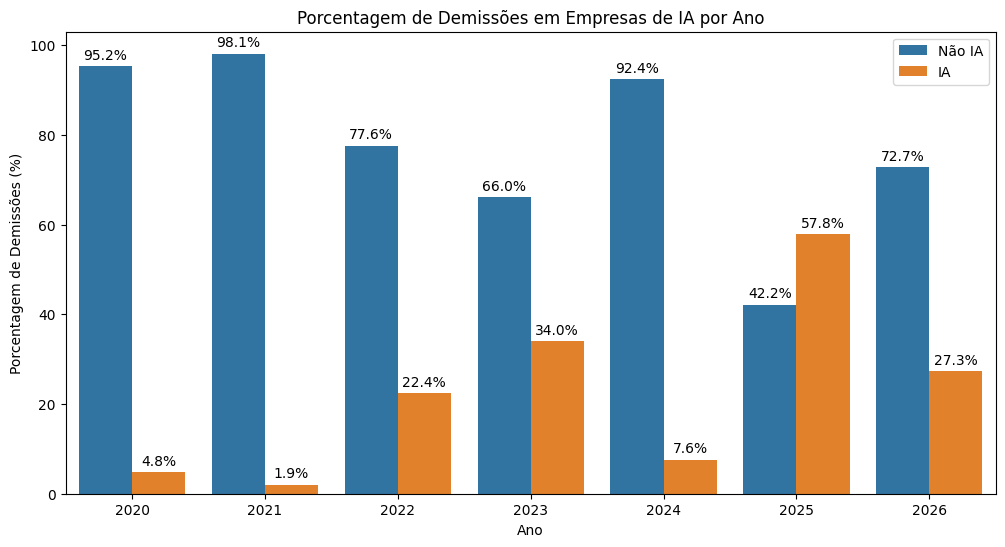

In [19]:
#Processando os dados
df= pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
df['layoff_year'] = pd.to_datetime(df['date']).dt.year #Criando uma nova coluna para indicar o ano da demissão
layoffs_by_year = df.groupby(['layoff_year', 'is_ai_company'])['layoff_count'].sum().reset_index() #Agrupando os dados por ano e tipo de empresa, além de soma das demissões para cada grupo
total_layoffs_by_year = df.groupby('layoff_year')['layoff_count'].sum().reset_index() #Calculando a porcentagem de demissões em empresas de IA em relação ao total de demissões para cada ano
total_layoffs_by_year.rename(columns={'layoff_count': 'total_layoffs'}, inplace=True) #Renomeando a coluna para facilitar a junção dos DataFrames
layoffs_by_year = layoffs_by_year.merge(total_layoffs_by_year, on='layoff_year') #Juntando os DataFrames (agora possui a coluna 'total_layoffs')
layoffs_by_year['percentage'] = (layoffs_by_year['layoff_count'] / layoffs_by_year['total_layoffs']) * 100 #Calculando a porcentagem de demissões em empresas de IA para cada ano

#Criando o gráfico de barras
plt.figure(figsize=(12, 6)) #Definindo o tamanho da figura
ax = sns.barplot(data=layoffs_by_year, x='layoff_year', y='percentage', hue='is_ai_company') #X = anos, Yy = %demissões e as barras são coloridas de acordo com o tipo de empresa (IA ou não IA)
for container in ax.containers: #Adicionando rótulos de porcentagem nas barras, com uma casa decimal e um símbolo de porcentagem.
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.title('Porcentagem de Demissões em Empresas de IA por Ano')
plt.xlabel('Ano')
plt.ylabel('Porcentagem de Demissões (%)')
plt.legend(handles=ax.get_legend_handles_labels()[0], labels=['Não IA', 'IA'])
plt.savefig('P1.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 2
Quais os 5 setores com maior volume absoluto de demissões?

C:\Users\joaor\AppData\Local\Temp\ipykernel_26196\1103648084.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_5_industries, x='layoff_count', y='industry', palette='viridis') #Criando o gráfico de barras horizontal, com os setores no eixo y e o número total de demissões no eixo x


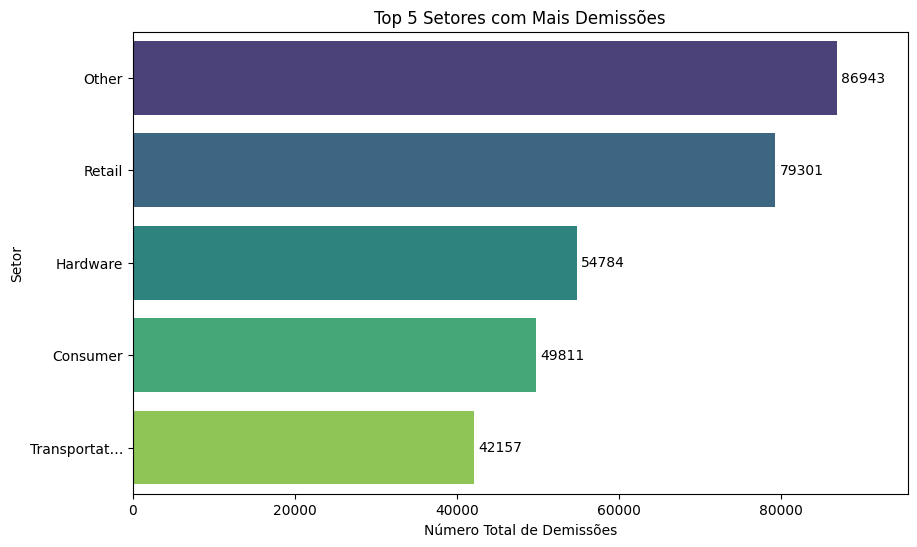

In [21]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
layoffs_by_industry = df.groupby('industry')['layoff_count'].sum().reset_index() #Agrupando os dados por setor e calculando a soma das demissões para cada setor
top_5_industries = layoffs_by_industry.sort_values(by='layoff_count', ascending=False).head(5) #Selecionando os 5 setores com mais demissões

#Criando o gráfico de barras
plt.figure(figsize=(10, 6)) #Definindo o tamanho da figura
ax = sns.barplot(data=top_5_industries, x='layoff_count', y='industry', palette='viridis') #Criando o gráfico de barras horizontal, com os setores no eixo y e o número total de demissões no eixo x
for container in ax.containers: #Adicionando rótulos de número total de demissões nas barras
    ax.bar_label(container, fmt='%d', padding=3) #Adicionando rótulos de número total de demissões nas barras, formatados como inteiros.
plt.title('Top 5 Setores com Mais Demissões')
plt.xlabel('Número Total de Demissões')
plt.ylabel('Setor')
plt.xlim(0, top_5_industries['layoff_count'].max() * 1.1) #Ajustando o limite do eixo x para dar espaço para os rótulos
plt.savefig('P2.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 3
Quais os países com maior volume de demissões registradas?

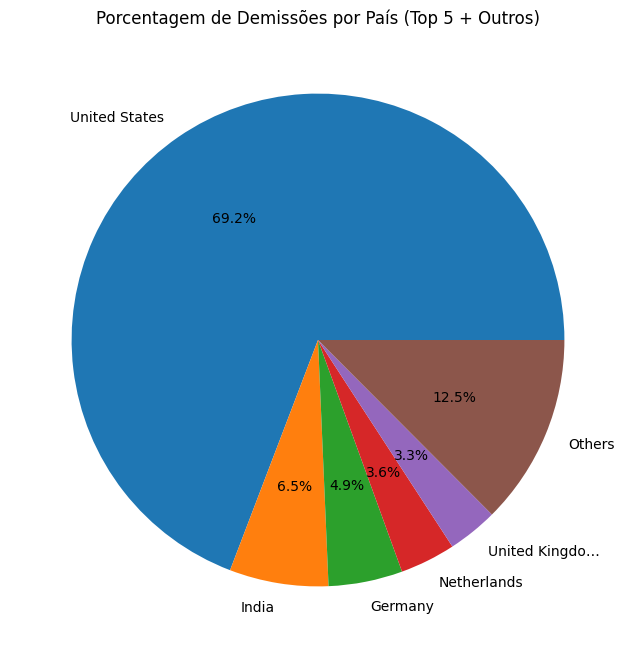

In [4]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando o dataframe
layoffs_by_country = df.groupby('country')['layoff_count'].sum().reset_index() #Agrupando os dados por PAÍS e somando as demissões
top_5_countries = layoffs_by_country.sort_values(by='layoff_count', ascending=False).head(5) #Selecionando os 5 PAÍSES com mais demissões
other_layoffs = layoffs_by_country[~layoffs_by_country['country'].isin(top_5_countries['country'])]['layoff_count'].sum() #Calculando as demissões do resto do mundo
linha_outros = pd.DataFrame([{'country': 'Others', 'layoff_count': other_layoffs}]) #Adicionando a linha "Outros" na tabela
top_5_countries = pd.concat([top_5_countries, linha_outros], ignore_index=True) #Concatenando a linha "Outros" com os top 5 países, criando um novo DataFrame que inclui os 5 países com mais demissões e a categoria "Outros" para o restante dos países.

#Criando o grafico de pizza
plt.figure(figsize=(10, 8)) 
plt.pie(top_5_countries['layoff_count'], labels=top_5_countries['country'], autopct='%1.1f%%',) #Criando a pizza (agora usando a coluna 'country' para os rótulos)
plt.title('Porcentagem de Demissões por País (Top 5 + Outros)')
plt.savefig('P3.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 4
Qual foi o ano com maior número de demissões?

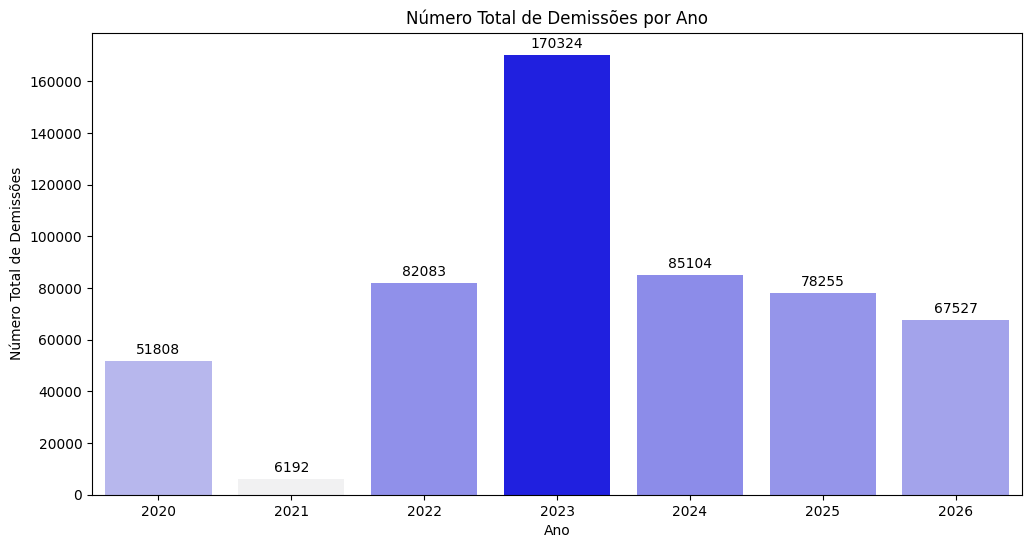

In [5]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
df['layoff_year'] = pd.to_datetime(df['date']).dt.year #Criando uma nova coluna para indicar o ano da demissão
layoffs_by_year = df.groupby('layoff_year')['layoff_count'].sum().reset_index() #Agrupando os dados por ano e calculando a soma das demissões para cada ano

#Criando o gráfico de barras
plt.figure(figsize=(12, 6)) #Definindo o tamanho da figura
ax = sns.barplot(data=layoffs_by_year, x='layoff_year', y='layoff_count', hue='layoff_count', palette='light:b', legend=False) 
for container in ax.containers: #Adicionando rótulos de número total de demissões nas barras
    ax.bar_label(container, fmt='%d', padding=3) #Adicionando rótulos de número total de demissões nas barras.
plt.title('Número Total de Demissões por Ano')
plt.xlabel('Ano')
plt.ylabel('Número Total de Demissões')
plt.savefig('P4.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 5
Quais as regiões/cidades com mais demissões registradas?

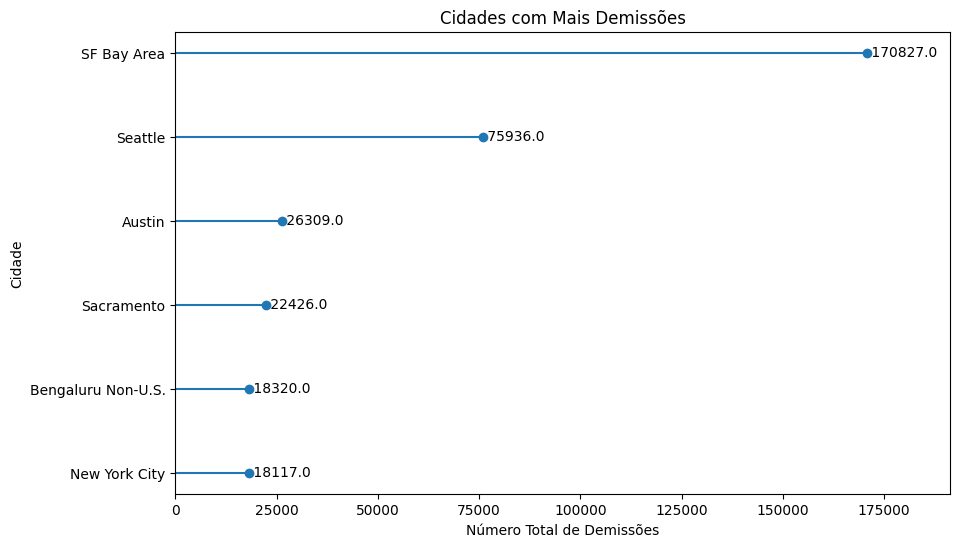

In [6]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
layoffs_by_city = df.groupby('location')['layoff_count'].sum().reset_index() #Agrupando os dados por cidade e calculando a soma das demissões para cada cidade
top_6_cities = layoffs_by_city.sort_values(by='layoff_count', ascending=False).head(6) #Selecionando as 6 cidades com mais demissões

#Criando o gráfico de barras
plt.figure(figsize=(10, 6)) #Definindo o tamanho da figura
ax = plt.subplot(111) #Criando um subplot
ax.stem(top_6_cities['location'], top_6_cities['layoff_count'], basefmt=" ", orientation='horizontal', ) #Criando um gráfico de barras horizontal usando o método stem, com as cidades no eixo y e o número total de demissões no eixo x
for i, count in enumerate(top_6_cities['layoff_count']): #Adicionando rótulos de número total de demissões nas barras.
    ax.text(count, i, f' {str(count)}', ha='left', va='center')
plt.title('Cidades com Mais Demissões')
plt.xlabel('Número Total de Demissões')
plt.ylabel('Cidade')
ax.invert_yaxis() #Decrescente
plt.xlim(0, top_6_cities['layoff_count'].max() * 1.12) #Ajustando o limite do eixo x para dar espaço para os rótulos   
plt.savefig('P5.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 6
Quais empresas realizaram mais demissões no total?


C:\Users\joaor\AppData\Local\Temp\ipykernel_26196\998992364.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_companies, x='layoff_count', y='company', palette='Purples_r') #Criando o gráfico de barras horizontal, com as empresas no eixo y e o número total de demissões no eixo x


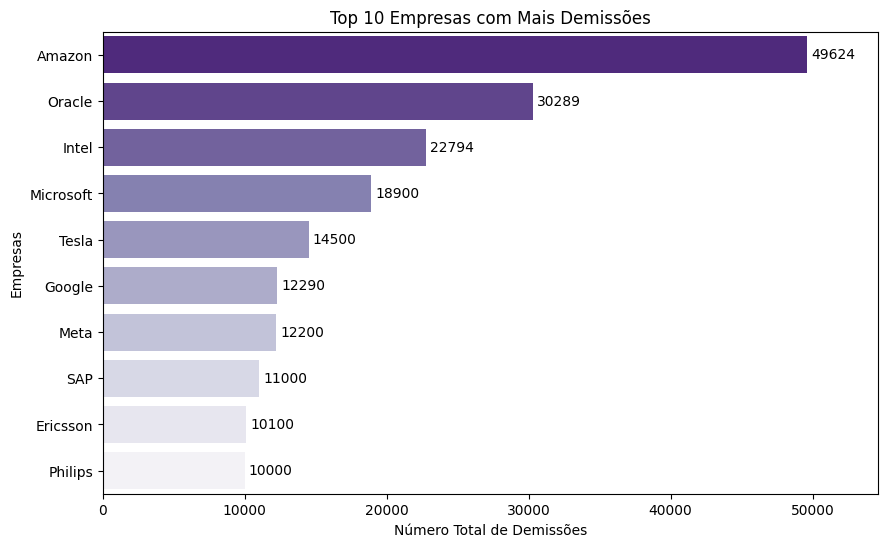

In [7]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
layoffs_by_company = df.groupby('company')['layoff_count'].sum().reset_index() #Agrupando os dados por empresa e calculando a soma das demissões para cada empresa
top_10_companies = layoffs_by_company.sort_values(by='layoff_count', ascending=False).head(10) #Selecionando as 10 empresas com mais demissões

#Criando o gráfico de barras
plt.figure(figsize=(10, 6)) #Definindo o tamanho da figura
ax = sns.barplot(data=top_10_companies, x='layoff_count', y='company', palette='Purples_r') #Criando o gráfico de barras horizontal, com as empresas no eixo y e o número total de demissões no eixo x
for container in ax.containers: #Adicionando rótulos de número total de demissões nas barras
    ax.bar_label(container, fmt='%d', padding=3)
plt.title('Top 10 Empresas com Mais Demissões')
plt.xlabel('Número Total de Demissões')
plt.xlim(0, top_10_companies['layoff_count'].max() * 1.1) #Ajustando o limite do eixo x para dar espaço para os rótulos
plt.ylabel('Empresas')
plt.savefig('P6.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 7
Empresas que captaram mais capital demitem mais funcionários?

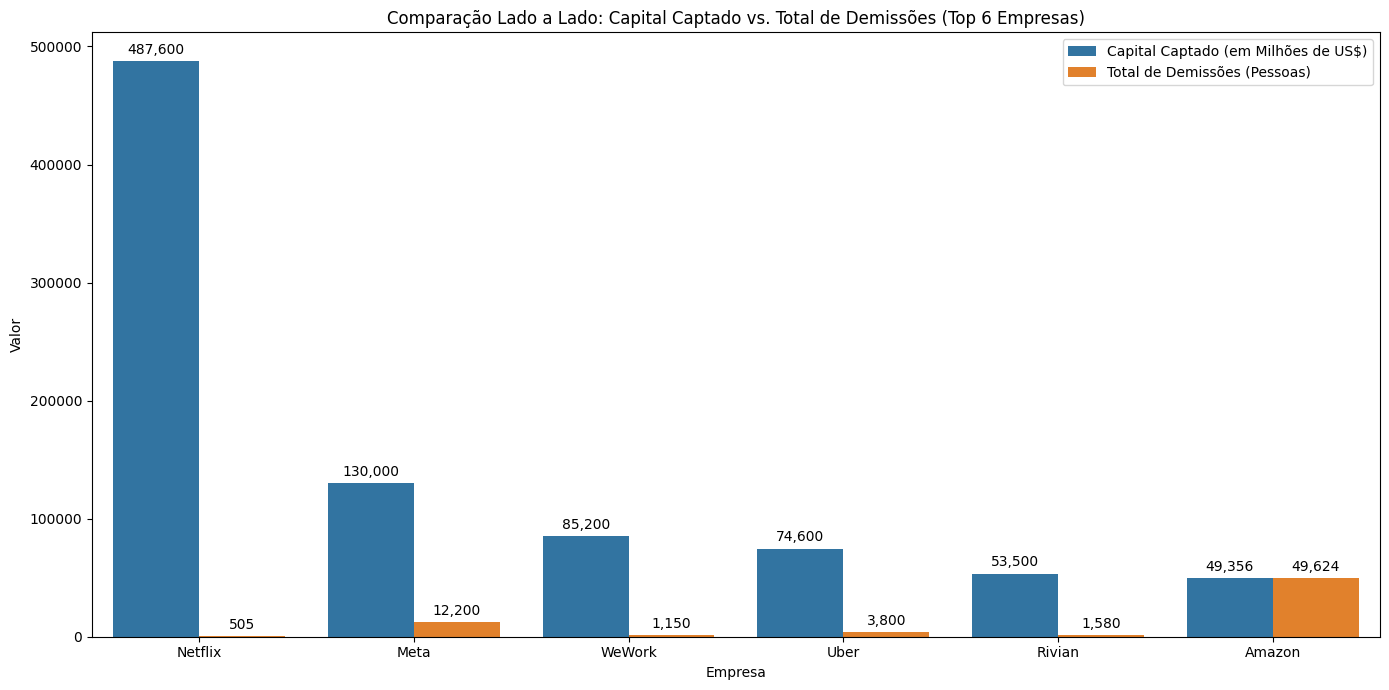

In [8]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls")
df['raised_mm'] = df['raised_mm'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
company_data = df.groupby('company')[['raised_mm', 'layoff_count']].sum().reset_index() #Agrupando e somando os dados por empresa
top_6_empresas = company_data.sort_values(by='raised_mm', ascending=False).head(6) #Selecionando as 6 empresas que MAIS captaram recursos
#MELT: Transformando colunas em categorias para fazer o gráfico agrupado. Isso transforma as colunas 'raised_mm' e 'layoff_count' em linhas rotuladas
top_6_melted = pd.melt(
    top_6_empresas, 
    id_vars=['company'], 
    value_vars=['raised_mm', 'layoff_count'],
    var_name='Métrica', 
    value_name='Valor'
)

#Criando o gráfico de barras
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=top_6_melted, x='company', y='Valor', hue='Métrica',) #O 'hue' agora separa as barras baseadas na 'Métrica'.
for container in ax.containers: # Adicionando os valores exatos em cima de cada barra
    textos_formatados = [f'{valor:,.0f}' for valor in container.datavalues]
    ax.bar_label(container, labels=textos_formatados, padding=3)
plt.title('Comparação Lado a Lado: Capital Captado vs. Total de Demissões (Top 6 Empresas)')
plt.xlabel('Empresa')
plt.ylabel('Valor')
plt.legend(handles=ax.get_legend_handles_labels()[0], labels=['Capital Captado (em Milhões de US$)', 'Total de Demissões (Pessoas)'])
plt.tight_layout()
plt.savefig('P7.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 8
Como o volume de demissões evoluiu ao longo dos anos?

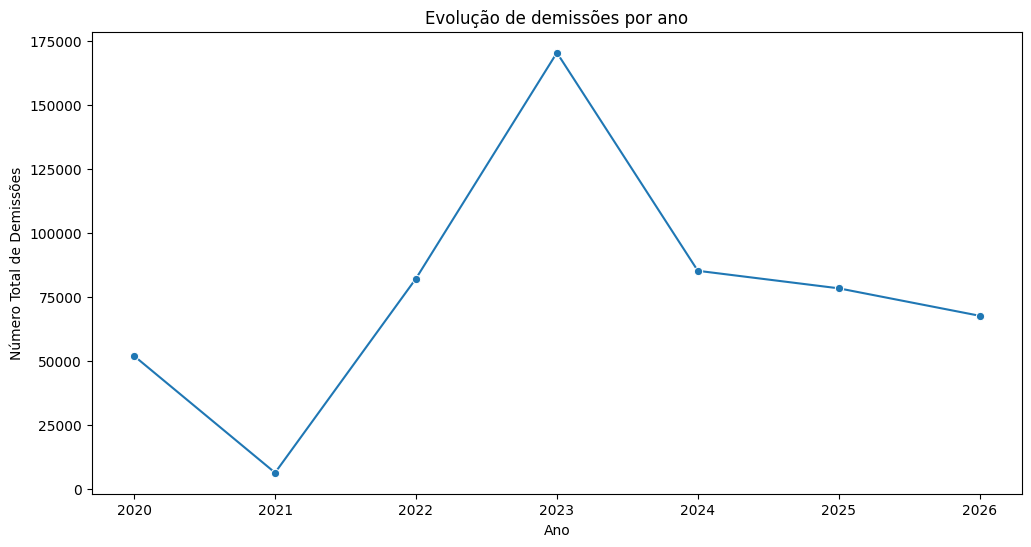

In [25]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
df['layoff_year'] = pd.to_datetime(df['date']).dt.year #Criando uma nova coluna para indicar o ano da demissão
layoffs_by_year = df.groupby('layoff_year')['layoff_count'].sum().reset_index() #Agrupando os dados por ano e calculando a soma das demissões para cada ano

#Criando o gráfico
plt.figure(figsize=(12, 6)) #Definindo o tamanho da figura
ax = sns.lineplot(data=layoffs_by_year, x='layoff_year', y='layoff_count', marker='o') #Criando um gráfico de linha, com os anos no eixo x e o número total de demissões no eixo y, e marcadores nos pontos de dados
plt.title('Evolução de demissões por ano') 
plt.xlabel('Ano')
plt.ylabel('Número Total de Demissões')
plt.savefig('P8.png', bbox_inches='tight', dpi=300)
plt.show()


---
### Pergunta 9
Em qual estágio de maturidade as empresas mais demitiram?

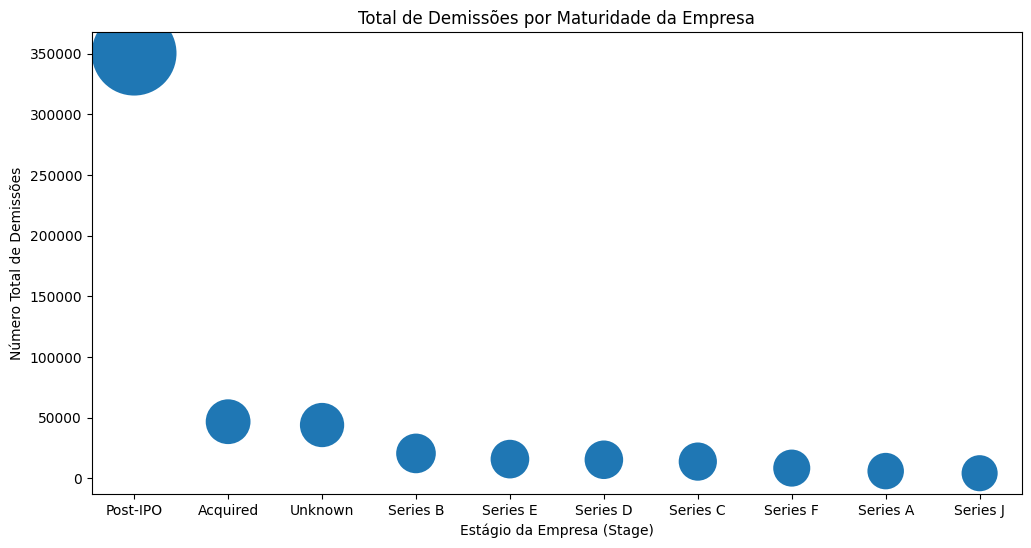

In [10]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") # Carregando os dados
layoffs_by_stage = df.groupby('stage')['layoff_count'].sum().reset_index() #Agrupando por estágio da empresa e somando as demissões, além de remover linhas com valores nulos
top_stages = layoffs_by_stage.sort_values(by='layoff_count', ascending=False).head(10) #Selecionando os 10 estágios com mais demissões

# Criando o grafico
plt.figure(figsize=(12, 6))
ax = sns.scatterplot( # Criando o gráfico de dispersão (scatter plot) vertical
    data=top_stages, 
    x='stage',               # Eixo X agora são os estágios (Vertical)
    y='layoff_count',        # Eixo Y agora são os valores
    size='layoff_count',     # O tamanho da bolinha cresce com o valor
    sizes=(800, 4000),       # Define um tamanho mínimo e máximo para as bolinhas ficarem visíveis
    legend=False
)
plt.title('Total de Demissões por Maturidade da Empresa')
plt.xlabel('Estágio da Empresa (Stage)')
plt.ylabel('Número Total de Demissões')
plt.savefig('P9.png', bbox_inches='tight', dpi=300)
plt.show()

---
### Pergunta 10
Em qual mês do ano historicamente ocorrem mais demissões?

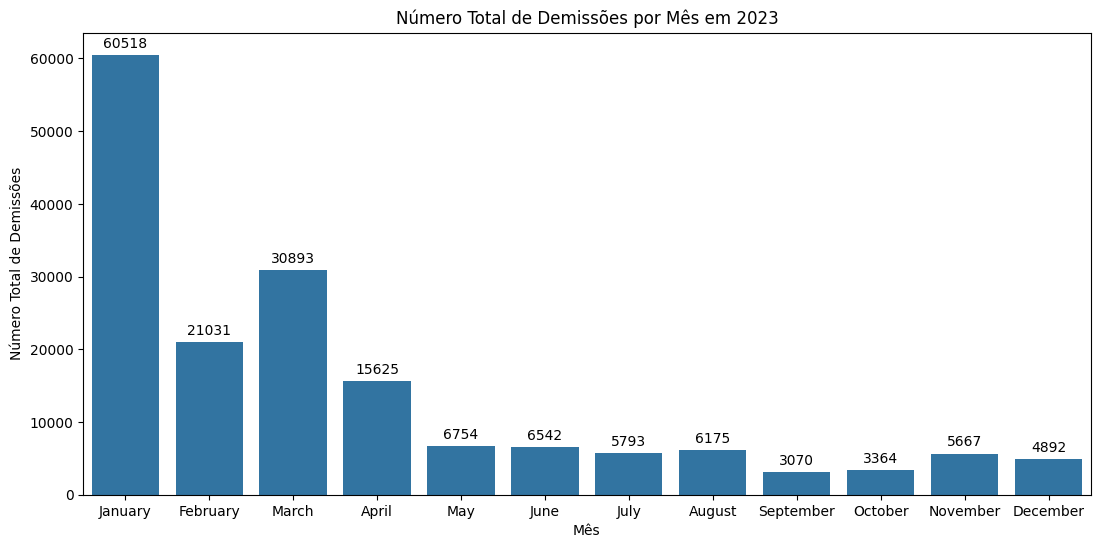

In [11]:
#Processando os dados
df = pd.read_csv("layoffs_events.csv.xls") #Criando dataframe
df['date'] = pd.to_datetime(df['date']) #Convertendo a coluna 'date' para o tipo datetime
df['month'] = df['date'].dt.month #Criando uma nova coluna para indicar o mês da demissão
df['year'] = df['date'].dt.year #Criando uma nova coluna para indicar o ano da demissão
demissoes_2023 = df[df['year'] == 2023].groupby('month')['layoff_count'].sum().reset_index() #Filtrando os dados para o ano de 2023 e agrupando por mês para calcular o número total de demissões por mês
demissoes_2023['month_name'] = demissoes_2023['month'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%B')) #Criando uma nova coluna com o nome do mês correspondente ao número do mês

#Criando grafico
plt.figure(figsize=(13, 6)) #Definindo o tamanho da figura
ax = sns.barplot(data=demissoes_2023, x='month_name', y='layoff_count') #Criando o gráfico de barras, com os nomes dos meses no eixo x e o número total de demissões no eixo y
for container in ax.containers: #Adicionando rótulos de número total de demissões nas barras
    ax.bar_label(container, fmt='%d', padding=3)
plt.title('Número Total de Demissões por Mês em 2023')
plt.xlabel('Mês')
plt.ylabel('Número Total de Demissões')
plt.savefig('P10.png', bbox_inches='tight', dpi=300)
plt.show()